# 01 — Preparación de datos: Sector Salud CDMX

**Fuente:** DENUE INEGI, mayo 2025 — Entidad 09 (Ciudad de México)  
**Objetivo:** Extraer y limpiar todos los establecimientos del sector salud (SCIAN 62) para análisis posterior.

---

## 0. Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

load_dotenv()

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

---
## 1. Carga del archivo DENUE

In [ ]:
RAW_URL = os.getenv("DENUE_CDMX_URL")  # URL del zip en Azure (con SAS token)
RAW_PATH = 'denue_inegi_09_.csv'       # fallback: archivo local si existe

source = RAW_PATH if os.path.exists(RAW_PATH) else RAW_URL
print(f'Fuente: {"local" if source == RAW_PATH else "URL remota"}')

# Lectura por chunks: filtra sector salud (SCIAN 62) al vuelo
chunks = []
for chunk in pd.read_csv(
    source,
    encoding='latin-1',
    dtype=str,
    compression='zip' if str(source).endswith('.zip') else 'infer',
    chunksize=50_000
):
    chunks.append(chunk[chunk['codigo_act'].str.startswith('62', na=False)])

df_raw = pd.concat(chunks, ignore_index=True)

print(f'Registros sector salud (CDMX): {len(df_raw):,}')
print(f'Columnas: {df_raw.shape[1]}')
df_raw.head(2)

---
## 2. Filtro: Sector Salud (SCIAN 62)

El sector 62 del SCIAN agrupa:

| Subsector | Descripción |
|-----------|-------------|
| 621 | Servicios médicos ambulatorios (consultorios, dentistas, laboratorios…) |
| 622 | Hospitales |
| 623 | Residencias de asistencia social y para el cuidado de la salud |
| 624 | Servicios de asistencia social |

> **Nota:** No se eliminan coordenadas duplicadas, ya que distintos establecimientos pueden ocupar el mismo inmueble.

In [ ]:
df_salud = df_raw.copy()

print(f'Registros sector salud: {len(df_salud):,}')
print(f'Actividades únicas    : {df_salud["codigo_act"].nunique()}')

---
## 3. Limpieza general de texto

In [50]:
TEXT_COLS = [
    'nom_estab', 'raz_social', 'nombre_act',
    'nom_vial', 'nom_v_e_1', 'nom_v_e_2', 'nom_v_e_3',
    'numero_ext', 'letra_ext', 'edificio', 'edificio_e',
    'numero_int', 'letra_int',
    'nomb_asent', 'nom_CenCom',
    'municipio', 'localidad', 'entidad',
    'telefono', 'correoelec', 'www'
]

for col in TEXT_COLS:
    if col in df_salud.columns:
        df_salud[col] = df_salud[col].str.strip()

# Strings vacíos -> NaN
df_salud.replace('', np.nan, inplace=True)

# Espacios múltiples en nom_estab -> un solo espacio
df_salud['nom_estab'] = df_salud['nom_estab'].str.replace(r'  +', ' ', regex=True)

# numero_ext: estandarizar variantes de "sin número" -> NaN
SN_VALS = {'SN', 'S/N', 'S.N.', 'S.N', '0'}
df_salud['numero_ext'] = df_salud['numero_ext'].apply(
    lambda x: np.nan if isinstance(x, str) and x.upper().strip() in SN_VALS else x
)

# cod_postal: restaurar cero inicial en códigos de 4 dígitos (CDMX empieza en 0)
df_salud['cod_postal'] = df_salud['cod_postal'].apply(
    lambda x: x.zfill(5) if isinstance(x, str) and x.isdigit() and len(x) == 4 else x
)

n_sn  = df_salud['numero_ext'].isna().sum()
n_cp  = (df_salud['cod_postal'].str.len() == 5).sum()
print('Texto limpiado correctamente.')
print(f'  numero_ext sin número -> NaN : {n_sn}')
print(f'  cod_postal de 5 dígitos      : {n_cp}')

Texto limpiado correctamente.
  numero_ext sin número -> NaN : 3175
  cod_postal de 5 dígitos      : 22663


---
## 4. Tipos de datos

In [51]:
# Coordenadas
df_salud['latitud']  = pd.to_numeric(df_salud['latitud'],  errors='coerce')
df_salud['longitud'] = pd.to_numeric(df_salud['longitud'], errors='coerce')

# Fecha de alta (formato YYYY-MM del DENUE)
df_salud['fecha_alta'] = pd.to_datetime(df_salud['fecha_alta'], format='%Y-%m', errors='coerce')

# ID numérico
df_salud['id'] = pd.to_numeric(df_salud['id'], errors='coerce').astype('Int64')

# Tamaño del establecimiento: categórica ordinal
PER_OCU_ORDER = [
    '0 a 5 personas',
    '6 a 10 personas',
    '11 a 30 personas',
    '31 a 50 personas',
    '51 a 100 personas',
    '101 a 250 personas',
    '251 y más personas'
]
df_salud['per_ocu'] = pd.Categorical(
    df_salud['per_ocu'],
    categories=PER_OCU_ORDER,
    ordered=True
)

print('Tipos de datos asignados.')
df_salud[['id', 'latitud', 'longitud', 'fecha_alta', 'per_ocu']].dtypes

Tipos de datos asignados.


id                     Int64
latitud              float64
longitud             float64
fecha_alta    datetime64[ns]
per_ocu             category
dtype: object

In [52]:
# Punto medio numérico de per_ocu (útil para análisis cuantitativo)
PER_OCU_MIDPOINT = {
    '0 a 5 personas'      :   3,
    '6 a 10 personas'     :   8,
    '11 a 30 personas'    :  20,
    '31 a 50 personas'    :  40,
    '51 a 100 personas'   :  75,
    '101 a 250 personas'  : 175,
    '251 y más personas'  : 251
}
df_salud['per_ocu_num'] = df_salud['per_ocu'].map(PER_OCU_MIDPOINT)

print('per_ocu_num — estadísticas básicas:')
print(df_salud['per_ocu_num'].describe().round(1))

per_ocu_num — estadísticas básicas:
count     22841
unique        7
top           3
freq      19191
Name: per_ocu_num, dtype: int64


---
## 5. Columna auxiliar: subsector

In [53]:
SUBSECTOR_MAP = {
    '621': 'Servicios ambulatorios',
    '622': 'Hospitales',
    '623': 'Residencias y cuidado',
    '624': 'Asistencia social'
}

df_salud['subsector'] = df_salud['codigo_act'].str[:3].map(SUBSECTOR_MAP)

# Clasificación público / privado / no gubernamental
# Ambulancias (621910) y enfermería a domicilio (621610) se descartan
DESCARTAR = {"621910", "621610"}
df_salud = df_salud[~df_salud["codigo_act"].isin(DESCARTAR)].copy()

def clasificar_sector(row):
    nombre = row["nombre_act"].lower() if isinstance(row["nombre_act"], str) else ""
    if "sector público" in nombre:
        return "Público"
    if "sector privado" in nombre:
        return "Privado"
    # Sin distinción: clasificar por código
    if row["codigo_act"] == "621320":   # optometría -> comercial
        return "Privado"
    if row["codigo_act"] == "624191":   # AA y autoayuda -> civil
        return "No gubernamental"
    return "No especificado"  # fallback (no debería quedar ninguno)

df_salud['sector'] = df_salud.apply(clasificar_sector, axis=1)

print(f'Registros tras descartar ambulancias y enfermería a domicilio: {len(df_salud):,}')
print('\n=== Subsector ===')
print(df_salud['subsector'].value_counts())
print('\n=== Sector público / privado ===')
print(df_salud['sector'].value_counts())

Registros tras descartar ambulancias y enfermería a domicilio: 22,816

=== Subsector ===
subsector
Servicios ambulatorios    18941
Asistencia social          3174
Hospitales                  373
Residencias y cuidado       328
Name: count, dtype: int64

=== Sector público / privado ===
sector
Privado             19491
Público              2061
No gubernamental     1264
Name: count, dtype: int64


---
## 6. Revisión de valores faltantes

In [54]:
nulls = df_salud.isnull().mean().mul(100).round(2)
nulls = nulls[nulls > 0].sort_values(ascending=False)

print('Columnas con valores faltantes (% nulos):')
print(nulls.to_string())

Columnas con valores faltantes (% nulos):
letra_int     91.46
www           89.27
tipoCenCom    77.72
num_local     77.50
nom_CenCom    77.48
raz_social    75.99
edificio_e    75.76
edificio      75.60
letra_ext     70.43
correoelec    66.26
telefono      57.99
numero_int    44.49
numero_ext    13.91
cod_postal     0.77
tipo_asent     0.03
nom_v_e_3      0.02


In [55]:
sin_coords = df_salud[df_salud['latitud'].isna() | df_salud['longitud'].isna()]
print(f'Registros sin coordenadas: {len(sin_coords):,} '
      f'({len(sin_coords)/len(df_salud)*100:.2f}% del total salud)')

Registros sin coordenadas: 0 (0.00% del total salud)


---
## 7. Validación de coordenadas

La CDMX está dentro de los rangos aproximados:  
- latitud: 19.05 – 19.60  
- longitud: –99.40 – –98.95

In [56]:
LAT_MIN, LAT_MAX = 19.05, 19.60
LON_MIN, LON_MAX = -99.40, -98.95

fuera_rango = df_salud[
    df_salud['latitud'].notna() & (
        (df_salud['latitud']  < LAT_MIN) | (df_salud['latitud']  > LAT_MAX) |
        (df_salud['longitud'] < LON_MIN) | (df_salud['longitud'] > LON_MAX)
    )
]

print(f'Registros con coordenadas fuera del rango CDMX: {len(fuera_rango)}')
if len(fuera_rango) > 0:
    display(fuera_rango[['id', 'nom_estab', 'municipio', 'latitud', 'longitud']].head(10))

Registros con coordenadas fuera del rango CDMX: 0


In [57]:
# Marcar coordenadas fuera de rango como NaN (no eliminar el registro)
mask_fuera = (
    df_salud['latitud'].notna() & (
        (df_salud['latitud']  < LAT_MIN) | (df_salud['latitud']  > LAT_MAX) |
        (df_salud['longitud'] < LON_MIN) | (df_salud['longitud'] > LON_MAX)
    )
)
df_salud.loc[mask_fuera, ['latitud', 'longitud']] = np.nan

print(f'Coordenadas inválidas neutralizadas: {mask_fuera.sum()}')

Coordenadas inválidas neutralizadas: 0


---
## 8. Revisión de duplicados de ID

In [58]:
dup_id = df_salud['id'].duplicated().sum()
print(f'IDs duplicados: {dup_id}')

if dup_id > 0:
    display(df_salud[df_salud['id'].duplicated(keep=False)]
            [['id', 'nom_estab', 'municipio', 'latitud', 'longitud']]
            .sort_values('id').head(10))

IDs duplicados: 0


---
## 9. Selección y orden final de columnas

In [59]:
COLS_FINAL = [
    # Identificación
    'id', 'clee', 'nom_estab', 'raz_social',
    # Actividad económica
    'codigo_act', 'nombre_act', 'subsector', 'sector',
    # Tamaño
    'per_ocu', 'per_ocu_num',
    # Ubicación administrativa
    'cve_mun', 'municipio', 'cod_postal',
    'tipo_asent', 'nomb_asent',
    'ageb', 'manzana',
    # Dirección
    'tipo_vial', 'nom_vial', 'numero_ext', 'letra_ext',
    'numero_int', 'letra_int',
    # Contacto
    'telefono', 'correoelec', 'www',
    # Tipo de unidad
    'tipoUniEco',
    # Coordenadas
    'latitud', 'longitud',
    # Temporalidad
    'fecha_alta'
]

df_clean = df_salud[COLS_FINAL].copy()

print(f'Shape final: {df_clean.shape}')
df_clean.head(3)

Shape final: (22816, 30)


,id,clee,nom_estab,raz_social,codigo_act,nombre_act,subsector,sector,per_ocu,per_ocu_num,cve_mun,municipio,cod_postal,tipo_asent,nomb_asent,ageb,manzana,tipo_vial,nom_vial,numero_ext,letra_ext,numero_int,letra_int,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
304457,11822253,09015621411000053000061236S6,MARIE STOPES CONDESA,FUNDACION MARIE STOPES MEXICO AC,621411,Centros de planificación familiar del sector privado,Servicios ambulatorios,Privado,11 a 30 personas,20,015,Cuauhtémoc,06140,COLONIA,CONDESA,1182,002,CALLE,Atlixco,12,NaN,NaN,NaN,5560512740,MAYRA.CRUZ@MARIESTOPES.ORG.MX,WWW.MARIESTOPES.ORG.MX,Fijo,19.415518,-99.172861,2025-04-01
304458,6795800,09013621511000421000003549S7,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,GRUPO DIAGNOSTICO MEDICO PROA SA DE CV,621511,Laboratorios médicos y de diagnóstico del sector privado,Servicios ambulatorios,Privado,0 a 5 personas,3,013,Xochimilco,16020,COLONIA,TEPEPAN,0014,015,CALLE,PASEO DE LA VIRGEN,610,NaN,NaN,NaN,NaN,INFORMES.WEB@CHOPO.COM.MX,WWW.CHOPO.COM.MX,Fijo,19.280340,-99.137950,2017-03-01
304459,8485187,09015624191001661000000000S0,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS ANONIMOS,DAMIAN INIESTRA ANTUNEZ AC,624191,Agrupaciones de autoayuda para alcohólicos y personas co...,Asistencia social,No gubernamental,0 a 5 personas,3,015,Cuauhtémoc,06220,MANZANA,11,0023,011,CALLE,LUDWING VAN BEETHOVEN,61,NaN,NaN,NaN,5587392626,NaN,NaN,Fijo,19.460542,-99.131678,2019-11-01


---
## 10. Estadísticas descriptivas

In [60]:
print('=== Distribución por subsector ===')
print(df_clean['subsector'].value_counts().to_string())

print('\n=== Top 15 actividades ===')
top_act = (
    df_clean.groupby(['codigo_act', 'nombre_act'])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='count')
)
display(top_act)

print('\n=== Distribución por alcaldía ===')
print(df_clean['municipio'].value_counts().to_string())

print('\n=== Distribución por tamaño (per_ocu) ===')
print(df_clean['per_ocu'].value_counts(sort=False).to_string())

=== Distribución por subsector ===
subsector
Servicios ambulatorios    18941
Asistencia social          3174
Hospitales                  373
Residencias y cuidado       328

=== Top 15 actividades ===


,codigo_act,nombre_act,count
0,621211,Consultorios dentales del sector privado,7287
1,621113,Consultorios de medicina especializada del sector privado,3160
2,621111,Consultorios de medicina general del sector privado,2793
3,621398,Otros consultorios del sector privado para el cuidado de...,1379
4,624191,Agrupaciones de autoayuda para alcohólicos y personas co...,1264
5,621511,Laboratorios médicos y de diagnóstico del sector privado,791
6,621331,Consultorios de psicología del sector privado,719
7,621320,Consultorios de optometría,637
8,621341,Consultorios del sector privado de audiología y de terap...,498
9,624112,Servicios de orientación y trabajo social para la niñez ...,453



=== Distribución por alcaldía ===
municipio
Iztapalapa                3375
Gustavo A. Madero         2681
Cuauhtémoc                2656
Benito Juárez             2069
Tlalpan                   1700
Miguel Hidalgo            1619
Coyoacán                  1501
Álvaro Obregón            1485
Venustiano Carranza        962
Azcapotzalco               890
Iztacalco                  827
Xochimilco                 799
Tláhuac                    795
La Magdalena Contreras     654
Cuajimalpa de Morelos      496
Milpa Alta                 307

=== Distribución por tamaño (per_ocu) ===
per_ocu
0 a 5 personas        19182
6 a 10 personas        1837
11 a 30 personas       1024
31 a 50 personas        244
51 a 100 personas       232
101 a 250 personas      155
251 y más personas      142


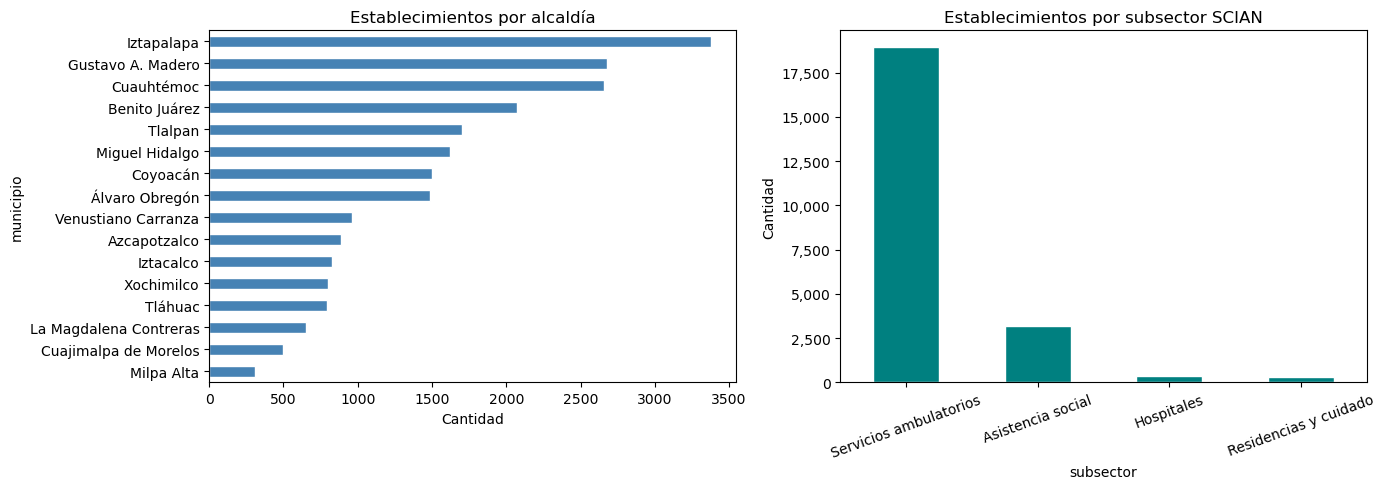

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Establecimientos por alcaldía
alcaldias = df_clean['municipio'].value_counts()
alcaldias.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Establecimientos por alcaldía', fontsize=12)
axes[0].set_xlabel('Cantidad')
axes[0].invert_yaxis()

# Establecimientos por subsector
df_clean['subsector'].value_counts().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white', rot=20
)
axes[1].set_title('Establecimientos por subsector SCIAN', fontsize=12)
axes[1].set_ylabel('Cantidad')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

---
## 10b. Público vs Privado

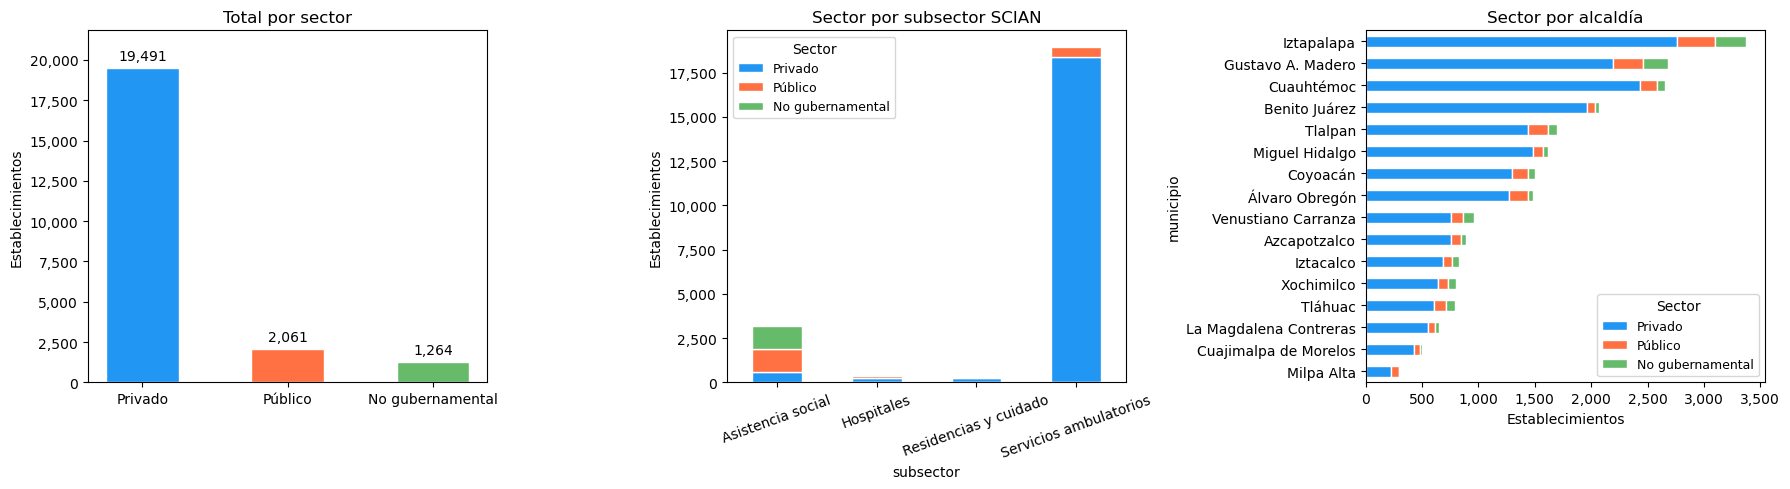

,establecimientos,porcentaje
sector,,
No gubernamental,1264,5.5
Privado,19491,85.4
Público,2061,9.0


In [62]:
COLORES = {
    'Privado'          : '#2196F3',
    'Público'          : '#FF7043',
    'No gubernamental' : '#66BB6A'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Total por sector ──────────────────────────────────────────────────────
totales = df_clean["sector"].value_counts()
bars = axes[0].bar(totales.index, totales.values,
                   color=[COLORES[s] for s in totales.index], edgecolor="white", width=0.5)
axes[0].bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=10)
axes[0].set_title("Total por sector", fontsize=12)
axes[0].set_ylabel("Establecimientos")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, totales.max() * 1.12)

# ── 2. Público vs Privado por subsector (barras apiladas) ────────────────────
pivot_sub = (
    df_clean.groupby(["subsector", "sector"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in ["Privado", "Público", "No gubernamental"] if c in df_clean["sector"].unique()])
)
pivot_sub.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[COLORES[c] for c in pivot_sub.columns],
    edgecolor="white", rot=20
)
axes[1].set_title("Sector por subsector SCIAN", fontsize=12)
axes[1].set_ylabel("Establecimientos")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(title="Sector", fontsize=9)

# ── 3. Público vs Privado por alcaldía (barras apiladas horizontales) ────────
pivot_alc = (
    df_clean.groupby(["municipio", "sector"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in ["Privado", "Público", "No gubernamental"] if c in df_clean["sector"].unique()])
)
pivot_alc["_total"] = pivot_alc.sum(axis=1)
pivot_alc = pivot_alc.sort_values("_total").drop(columns="_total")
pivot_alc.plot(
    kind="barh", stacked=True, ax=axes[2],
    color=[COLORES[c] for c in pivot_alc.columns],
    edgecolor="white"
)
axes[2].set_title("Sector por alcaldía", fontsize=12)
axes[2].set_xlabel("Establecimientos")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[2].legend(title="Sector", fontsize=9)

plt.tight_layout()
plt.show()

# Tabla resumen
resumen = df_clean.groupby("sector").size().rename("establecimientos").to_frame()
resumen["porcentaje"] = (resumen["establecimientos"] / len(df_clean) * 100).round(1)
display(resumen)

---
## 11. Exportar datos limpios

In [63]:
OUT_PATH = 'denue_salud_cdmx_clean.csv'

df_clean.to_csv(OUT_PATH, index=False, encoding='utf-8')

print(f'Archivo guardado: {OUT_PATH}')
print(f'  Registros : {len(df_clean):,}')
print(f'  Columnas  : {df_clean.shape[1]}')
print(f'  Con coords: {df_clean["latitud"].notna().sum():,}')

Archivo guardado: denue_salud_cdmx_clean.csv
  Registros : 22,816
  Columnas  : 30
  Con coords: 22,816


---
## Resumen del proceso

| Paso | Acción |
|------|--------|
| Carga | CSV con encoding `latin-1`, todo como `str` para preservar ceros |
| Filtro | `codigo_act` empieza con `62` → sector salud SCIAN |
| Texto | Strip de espacios, strings vacíos → `NaN` |
| Tipos | `latitud`/`longitud` → `float`, `fecha_alta` → `datetime`, `per_ocu` → categórica ordinal |
| Subsector | Columna auxiliar con los primeros 3 dígitos del código SCIAN |
| Coords | Registros fuera del bbox CDMX marcados como `NaN` (registro no eliminado) |
| Duplicados | Revisión de IDs duplicados; coords duplicadas se conservan intencionalmente |
| Exportación | `denue_salud_cdmx_clean.csv` en UTF-8 |